# User clustering

Segment users with at least five high ratings into taste personas. Each scaled column has one vote. Centers are learned on 80% of eligible users. The full fit includes rating habits. A second fit uses taste columns only. Both run for k = 2 through 15. Assignments are written only after `CHOSEN_K` and `CHOSEN_FIT` are set.


## 1. Load and build the cluster matrix

One row per user with `n_high >= 5`. Taste columns in this file are already means over ratings of 4 or 5. `cast_film_count_log` is the mean of the three actor film-count logs, so a famous cast gets one vote.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ROOT = Path("..")
PROCESSED = ROOT / "data" / "processed"
MIN_HIGH_RATINGS = 5
K_VALUES = range(2, 16)
RANDOM_STATE = 42
SILHOUETTE_SAMPLE_SIZE = 10_000
HABIT_COLS = ["log_n_ratings", "mean_rating", "user_rating_std"]

users = pd.read_csv(PROCESSED / "user_features.csv")
eligible = users.loc[users["n_high"] >= MIN_HIGH_RATINGS].reset_index(drop=True)

genre_cols = [c for c in eligible.columns if c.startswith("genre_") and c != "genre_entropy"]
eligible["log_n_ratings"] = np.log1p(eligible["n_ratings"])
eligible["cast_film_count_log"] = eligible[
    ["actor_1_film_count_log", "actor_2_film_count_log", "actor_3_film_count_log"]
].mean(axis=1)

cluster_cols = (
    HABIT_COLS
    + genre_cols
    + ["movie_age", "runtime", "budget_log", "director_film_count_log", "cast_film_count_log"]
)
taste_cols = [c for c in cluster_cols if c not in HABIT_COLS]
left_out = [
    "n_high",
    "pct_high",
    "pct_low",
    "genre_entropy",
    "log_roi",
    "lang_en",
    "movie_rating_std",
    "mean_rating_vs_movie",
]

missing = [c for c in cluster_cols if c not in eligible.columns]
if missing:
    raise ValueError(f"Missing cluster columns: {missing}")
if len(genre_cols) != 19 or len(cluster_cols) != 27 or len(taste_cols) != 24:
    raise ValueError(
        f"Expected 19 genres, 27 full columns, and 24 taste columns, "
        f"got {len(genre_cols)}, {len(cluster_cols)}, and {len(taste_cols)}"
    )
overlap = sorted(set(cluster_cols) & set(left_out))
if overlap:
    raise ValueError(f"Left-out columns entered the matrix: {overlap}")
if eligible[cluster_cols].isna().any().any():
    raise ValueError("Cluster matrix has missing values")

print(f"Eligible users (n_high >= {MIN_HIGH_RATINGS}): {len(eligible):,}")
print(f"Full columns ({len(cluster_cols)}): {cluster_cols}")
print(f"Taste columns ({len(taste_cols)}): {taste_cols}")


Eligible users (n_high >= 5): 431,528
Full columns (27): ['log_n_ratings', 'mean_rating', 'user_rating_std', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_war', 'genre_western', 'movie_age', 'runtime', 'budget_log', 'director_film_count_log', 'cast_film_count_log']
Taste columns (24): ['genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_war', 'genre_western', 'movie_age', 'runtime', 'budget_log', 'director_film_count_log', 'cast_film_count_log']


## 2. Train/test split

80% of eligible users define the centers. The other 20% are placed into those groups after the fit. Both feature sets use this same split.


In [ ]:
train_index, test_index = train_test_split(
    eligible.index, test_size=0.2, random_state=RANDOM_STATE
)
eligible["split"] = "test"
eligible.loc[train_index, "split"] = "train"
is_train = eligible["split"].eq("train").to_numpy()
train = eligible.loc[is_train].copy()

print(f"Train users: {int(is_train.sum()):,}")
print(f"Test users: {int((~is_train).sum()):,}")


Train users: 345,222
Test users: 86,306


## 3. Scale the full feature set on the train users

Standardize each cluster column with the train mean and standard deviation. Test users use that same scaling.


In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(eligible.loc[is_train, cluster_cols])
x_test = scaler.transform(eligible.loc[~is_train, cluster_cols])
x_scaled = np.empty((len(eligible), len(cluster_cols)), dtype=np.float64)
x_scaled[is_train] = x_train
x_scaled[~is_train] = x_test
print(f"Train matrix: {x_train.shape}")


Train matrix: (345222, 27)


## 4. Fit K-Means for k = 2 through 15

Centers are fit on the scaled train matrix only. Test users are assigned to the nearest train center.


In [ ]:
def fit_kmeans(x_train_matrix, x_test_matrix):
    labels_by_k = {}
    inertia_by_k = {}
    for k in K_VALUES:
        model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
        train_labels = model.fit_predict(x_train_matrix)
        test_labels = model.predict(x_test_matrix)
        labels = np.empty(len(eligible), dtype=np.int32)
        labels[is_train] = train_labels
        labels[~is_train] = test_labels
        labels_by_k[k] = labels
        inertia_by_k[k] = model.inertia_
        print(f"k={k}  inertia={model.inertia_:,.0f}")
    return labels_by_k, inertia_by_k


labels_full, inertia_full = fit_kmeans(x_train, x_test)


k=2  inertia=8,294,939


k=3  inertia=7,704,165


k=4  inertia=7,324,848


k=5  inertia=7,020,319


k=6  inertia=6,766,192


...

k=11  inertia=5,861,755


k=12  inertia=5,741,135


k=13  inertia=5,637,344


k=14  inertia=5,551,746


k=15  inertia=5,470,139


## 5. Full-model plots and heatmaps

Inertia uses every train user. Silhouette uses one fixed sample of 10,000 train users for every k. Each heatmap has one row per persona and one column per feature. The numbers behind the colors are persona means in original units. Color is centered and scaled within each column, so a genre share and a runtime can share the figure. The row label is the persona id and its share of train users.


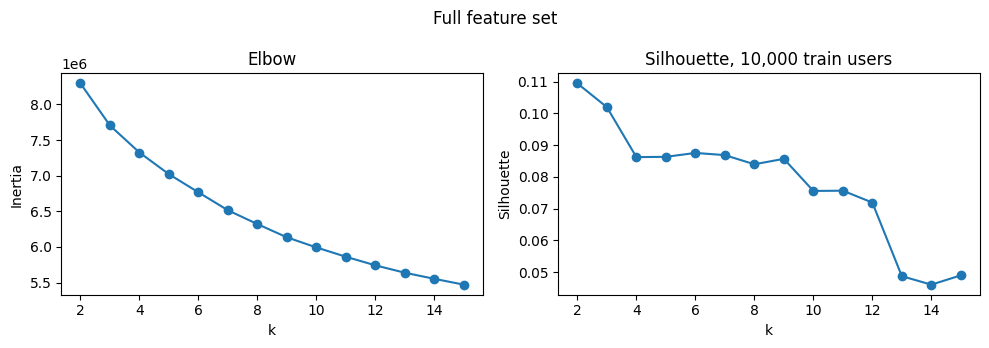

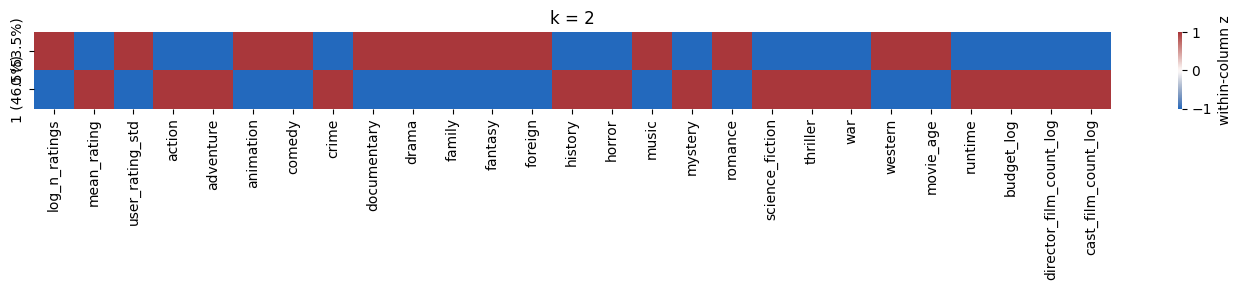

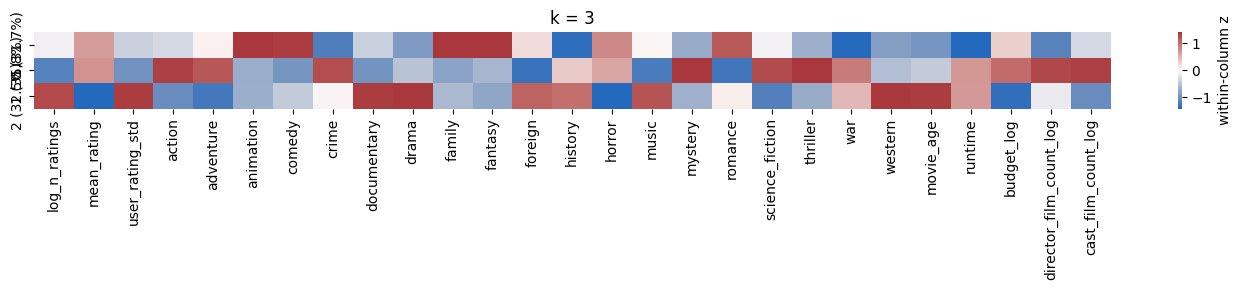

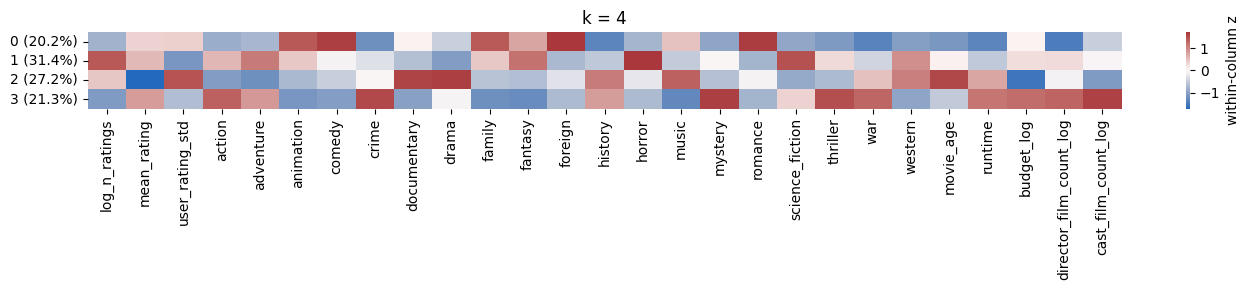

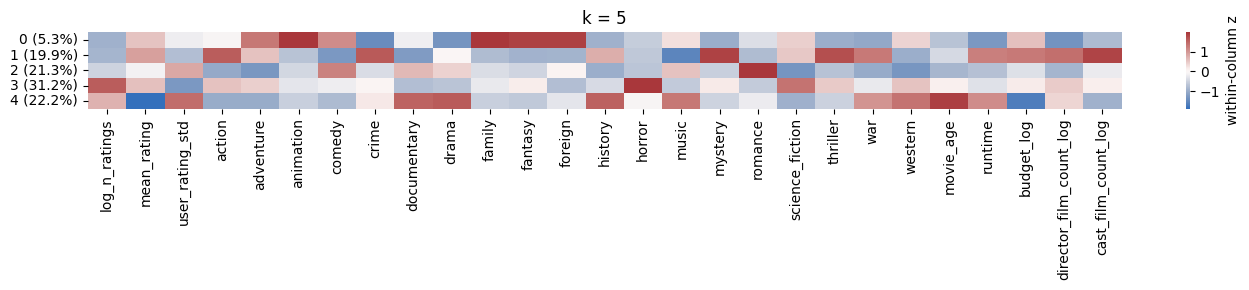

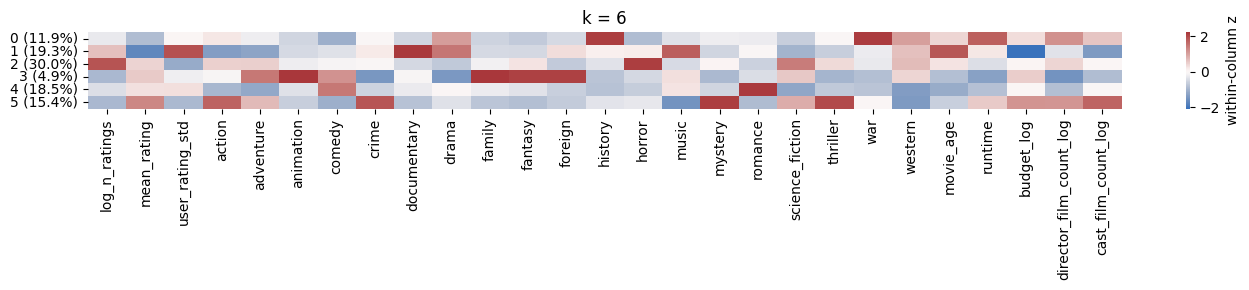

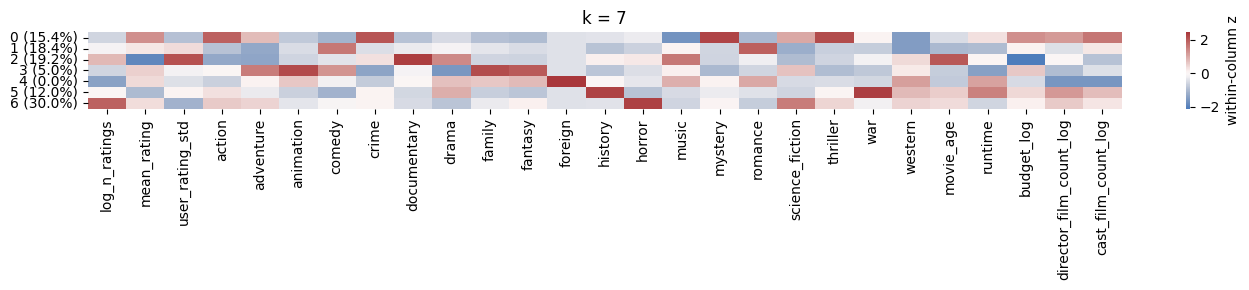

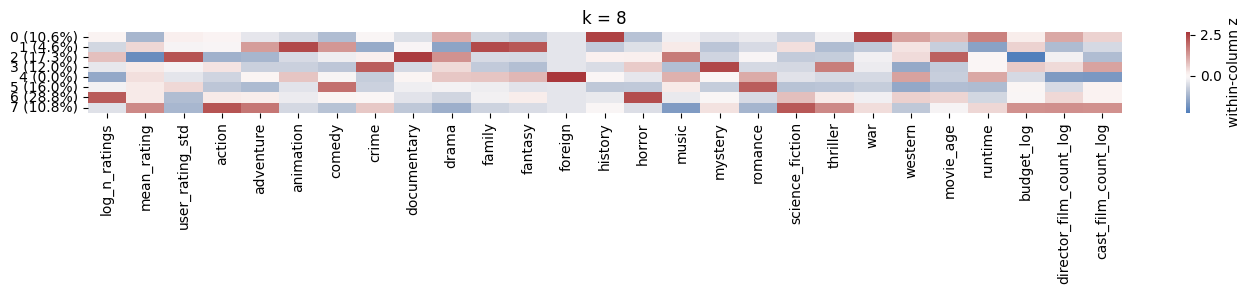

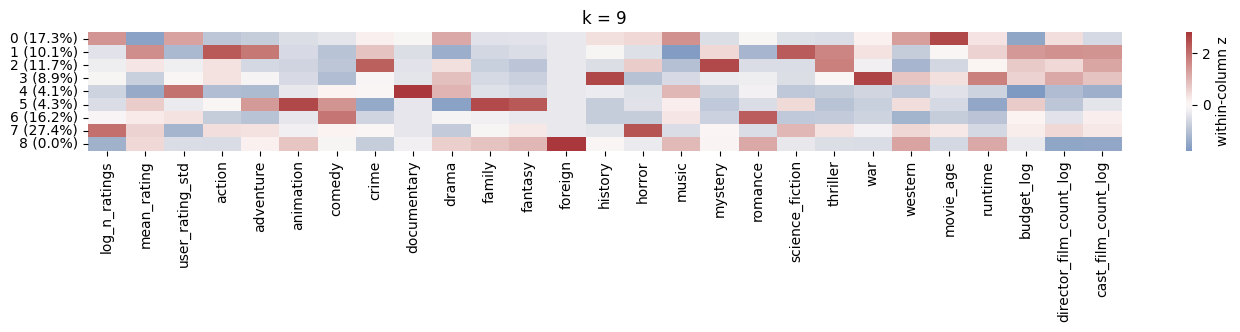

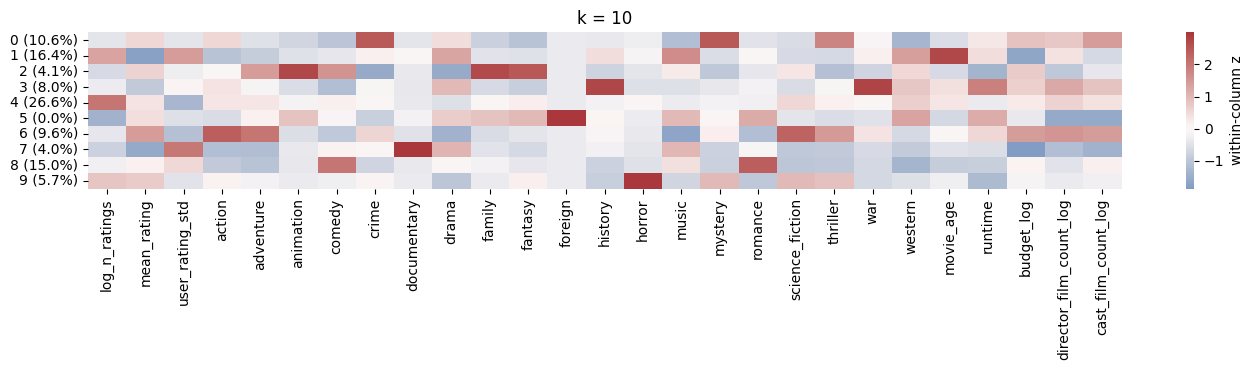

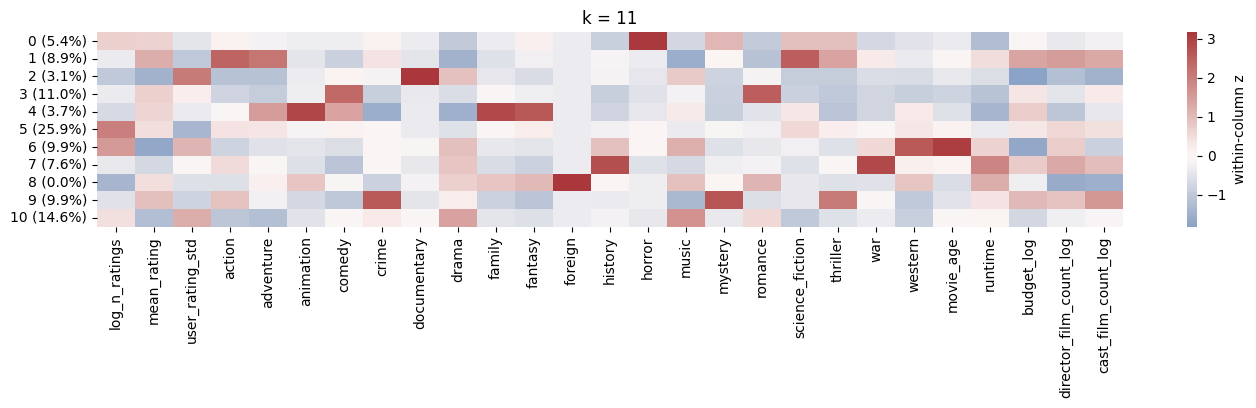

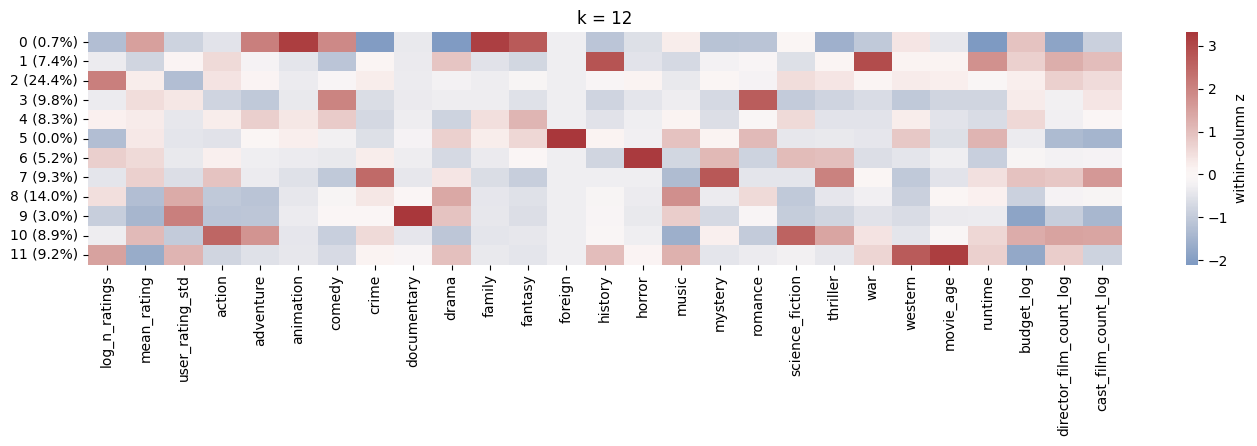

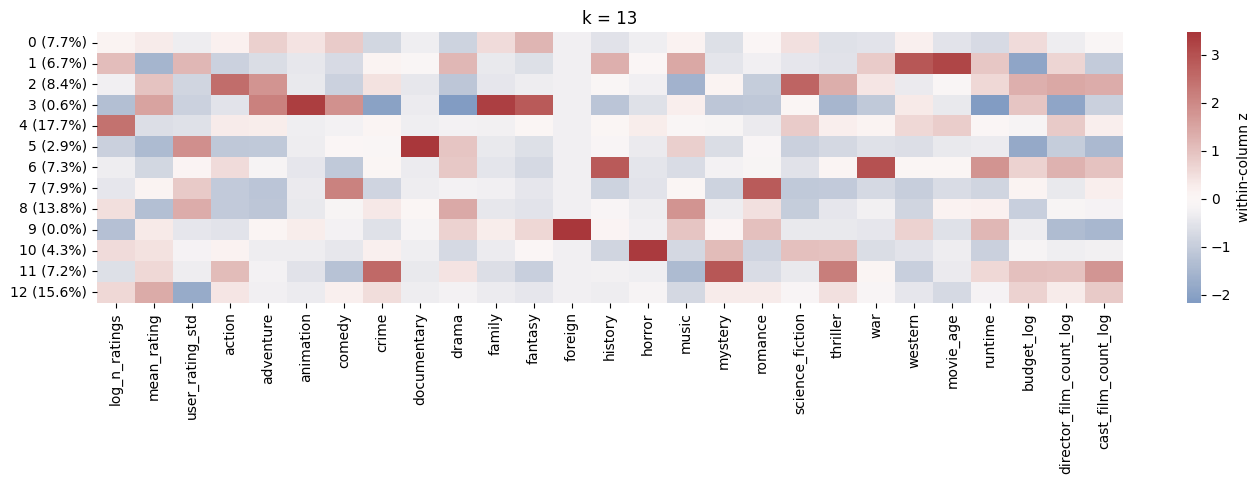

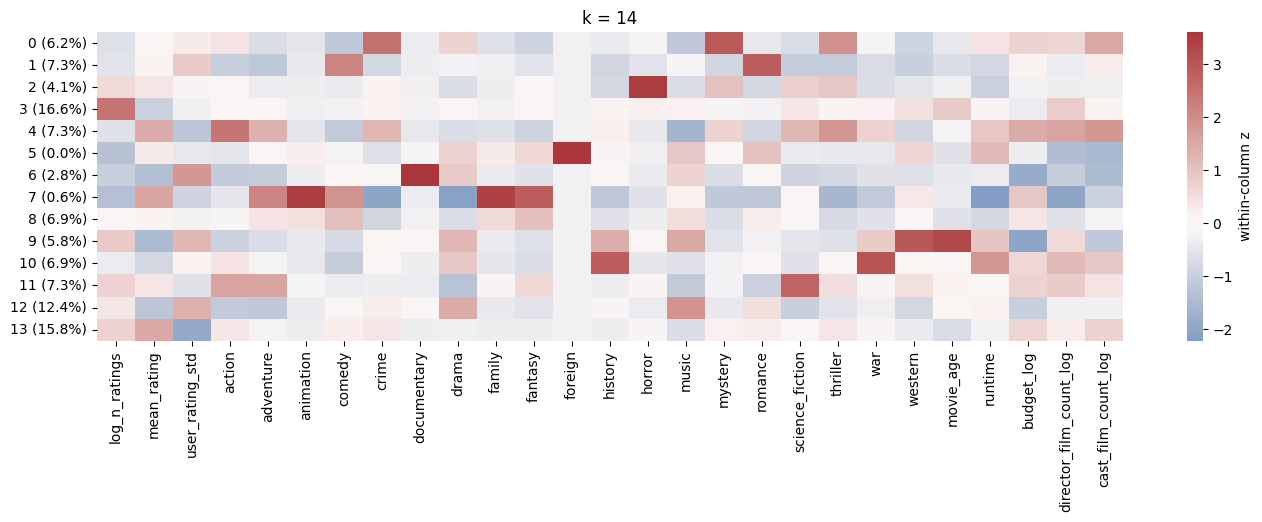

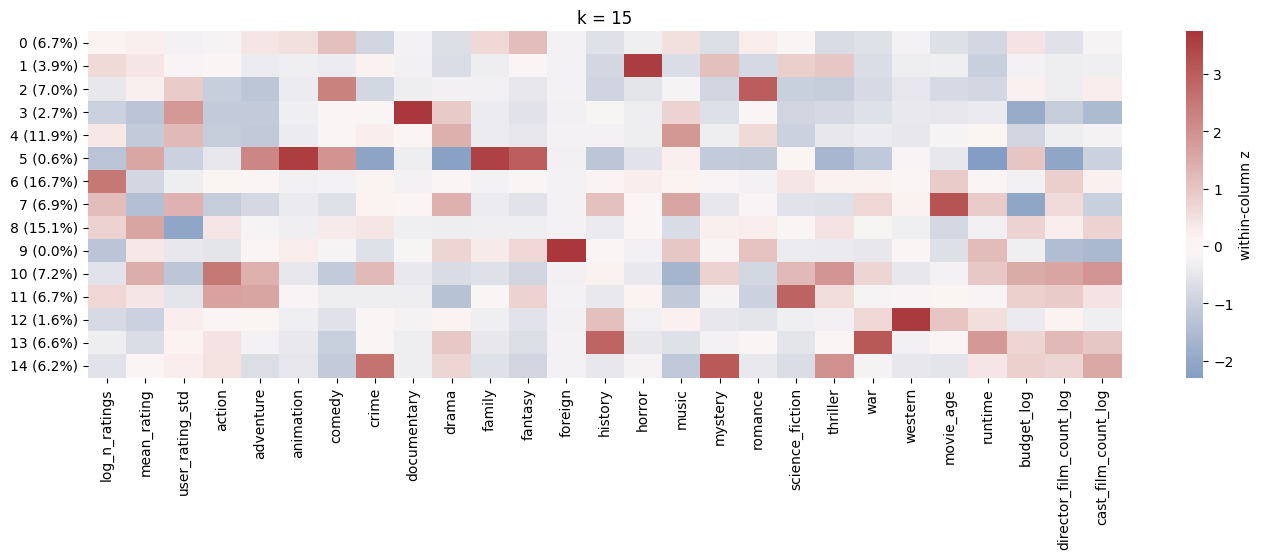

In [ ]:
# Same train users for every k and both feature sets, so silhouette differences come from the grouping.
sample_pool = np.flatnonzero(is_train)
silhouette_sample = np.random.default_rng(RANDOM_STATE).choice(
    sample_pool, size=SILHOUETTE_SAMPLE_SIZE, replace=False
)


def feature_label(column, unused_cols):
    label = column.removeprefix("genre_")
    if column in unused_cols:
        return f"{label} (not in fit)"
    return label


def column_color(means):
    # One shared color scale: each feature is centered and scaled across personas.
    centered = means - means.mean()
    scale = means.std(ddof=0).replace(0, np.nan)
    return centered.div(scale).fillna(0.0)


def silhouette_by_k(labels_by_k, x_for_score):
    scores = {}
    for k, labels in labels_by_k.items():
        scores[k] = silhouette_score(x_for_score[silhouette_sample], labels[silhouette_sample])
    return scores


def plot_fit_curves(inertia_by_k, silhouette_scores, title):
    ks = list(K_VALUES)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(ks, [inertia_by_k[k] for k in ks], marker="o")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertia")
    axes[0].set_title("Elbow")
    axes[1].plot(ks, [silhouette_scores[k] for k in ks], marker="o")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Silhouette")
    axes[1].set_title("Silhouette, 10,000 train users")
    fig.suptitle(title)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def plot_persona_heatmaps(labels_by_k, columns, unused_cols):
    for k in K_VALUES:
        labeled = train.copy()
        labeled["persona_id"] = labels_by_k[k][is_train]
        means = labeled.groupby("persona_id")[columns].mean().sort_index()
        share = labeled.groupby("persona_id").size().reindex(means.index)
        share = share / share.sum()
        colored = column_color(means)
        colored.index = [f"{persona_id} ({share.loc[persona_id]:.1%})" for persona_id in means.index]
        colored.columns = [feature_label(column, unused_cols) for column in columns]
        fig_height = max(10.0, 0.38 * k)
        fig, ax = plt.subplots(figsize=(14, fig_height))
        sns.heatmap(colored, center=0, cmap="vlag", ax=ax, cbar_kws={"label": "within-column z"})
        ax.set_title(f"k = {k}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelrotation=45)
        fig.tight_layout()
        display(fig)
        plt.close(fig)


silhouette_full = silhouette_by_k(labels_full, x_scaled)
plot_fit_curves(inertia_full, silhouette_full, "Full feature set")
plot_persona_heatmaps(labels_full, cluster_cols, unused_cols=())


## 6. Taste-only clustering

Drop `log_n_ratings`, `mean_rating`, and `user_rating_std` from the distance. Keep the 19 genres plus `movie_age`, `runtime`, `budget_log`, `director_film_count_log`, and `cast_film_count_log`. This scaler is fit on train users only, on those 24 columns. The heatmaps append the three habit columns, marked as not used in the fit. Inertia and silhouette here are not comparable to the full feature set.


Taste train matrix: (345222, 24)


k=2  inertia=7,272,881


k=3  inertia=6,696,948


k=4  inertia=6,358,221


k=5  inertia=6,073,386


...

k=11  inertia=4,945,631


k=12  inertia=4,827,295


k=13  inertia=4,736,317


k=14  inertia=4,655,360


k=15  inertia=4,578,787


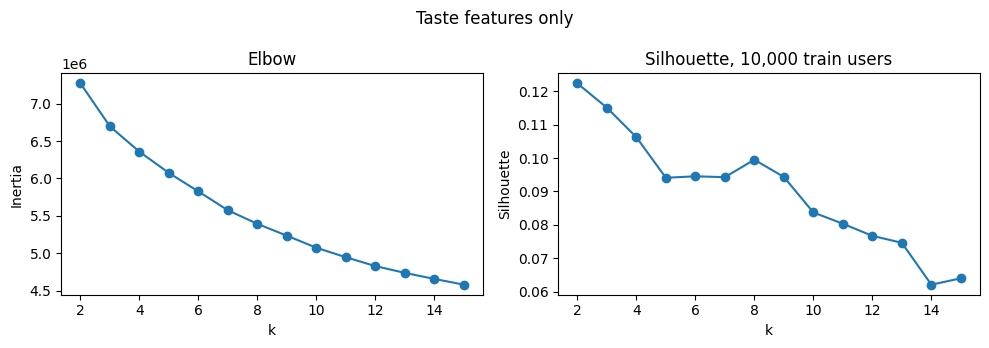

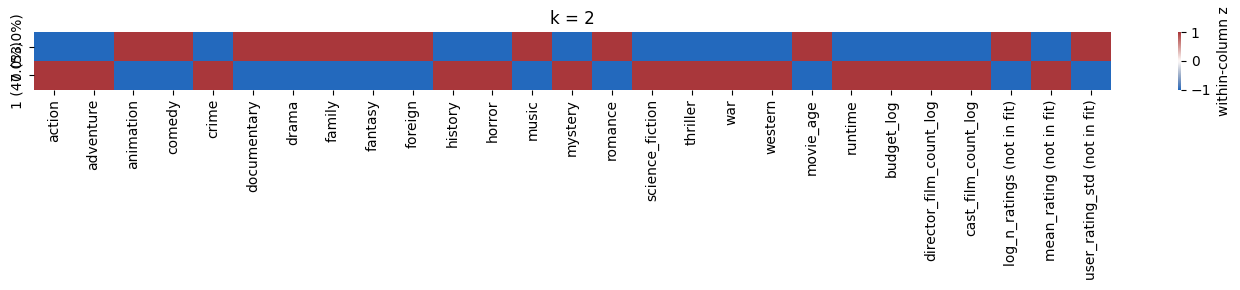

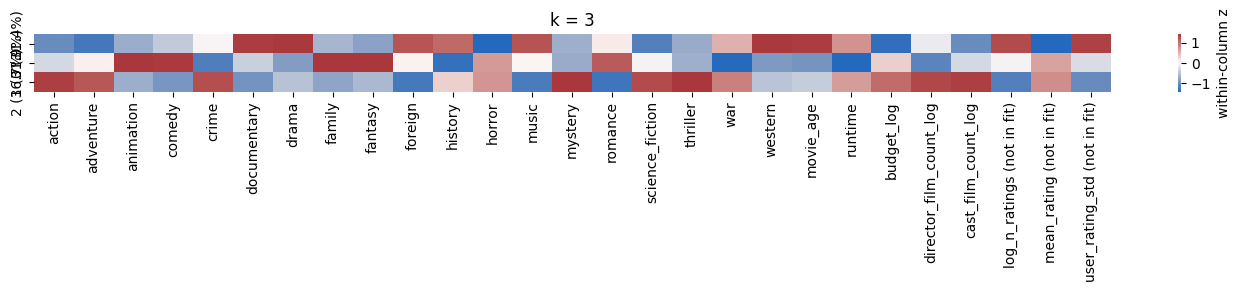

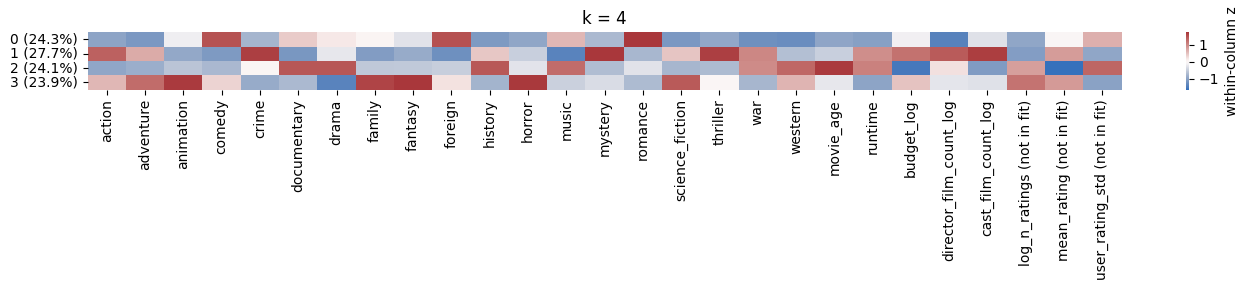

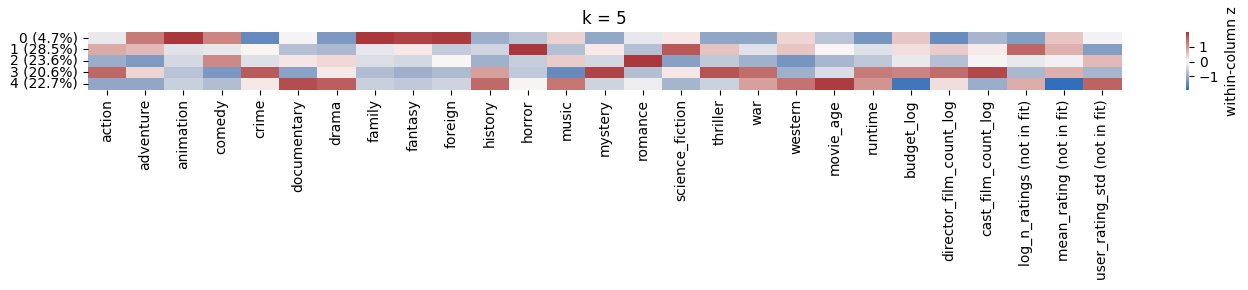

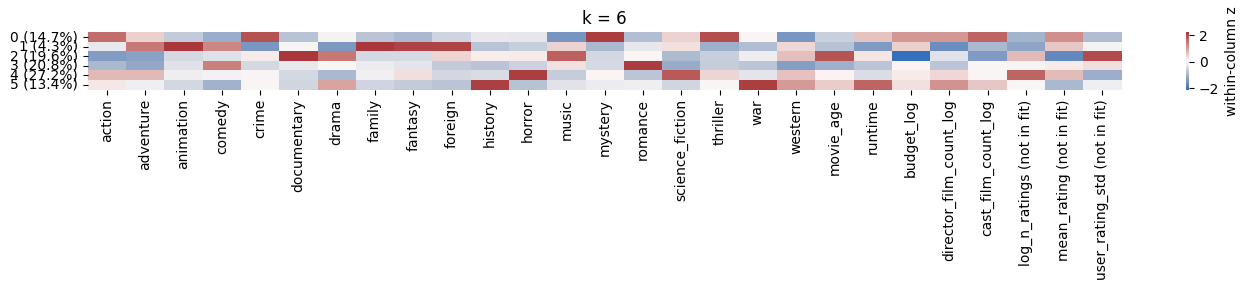

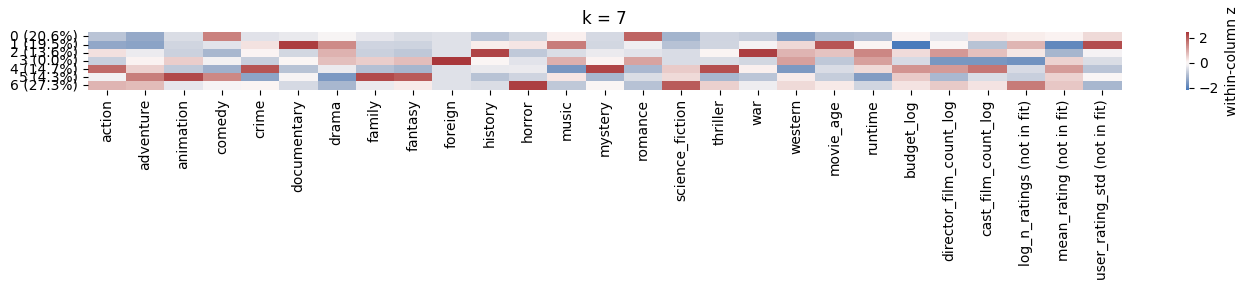

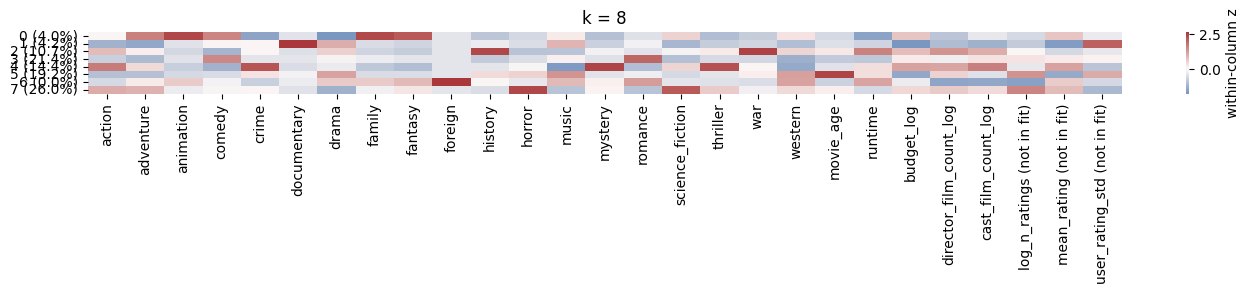

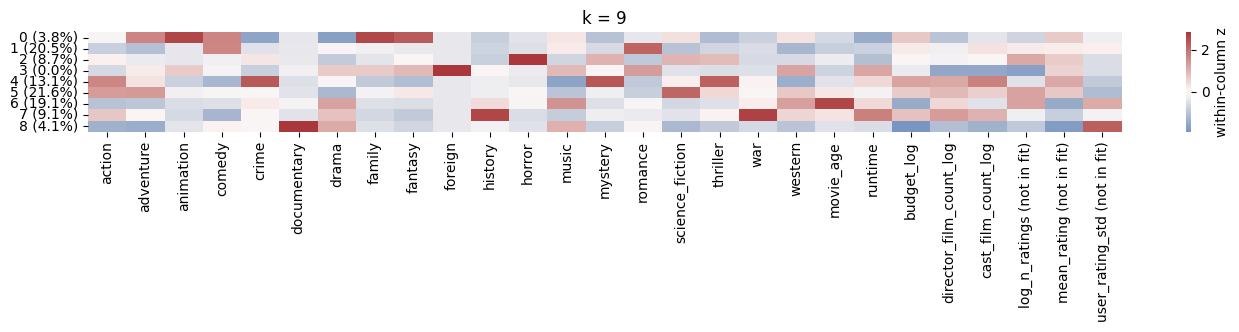

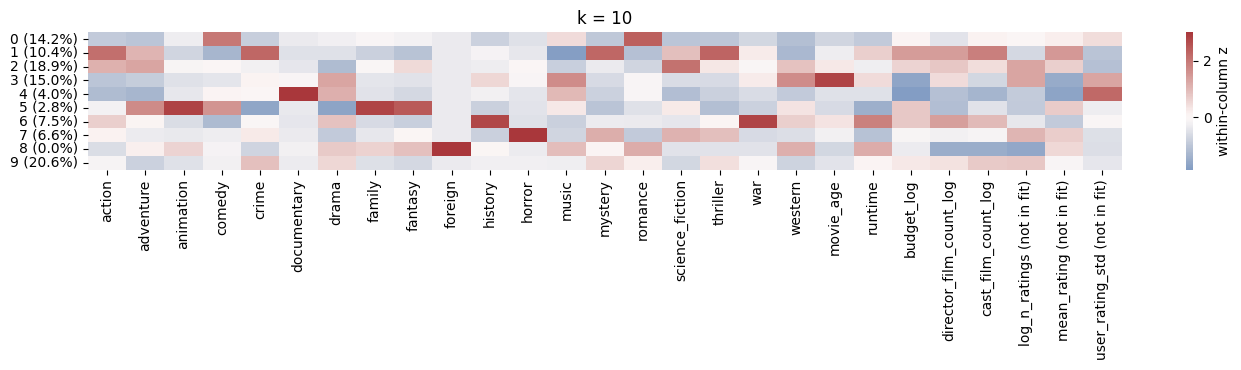

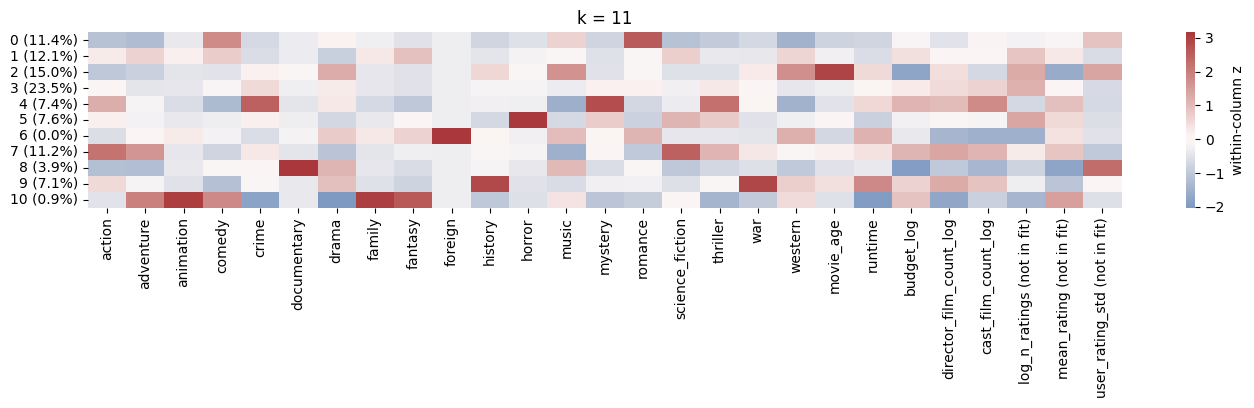

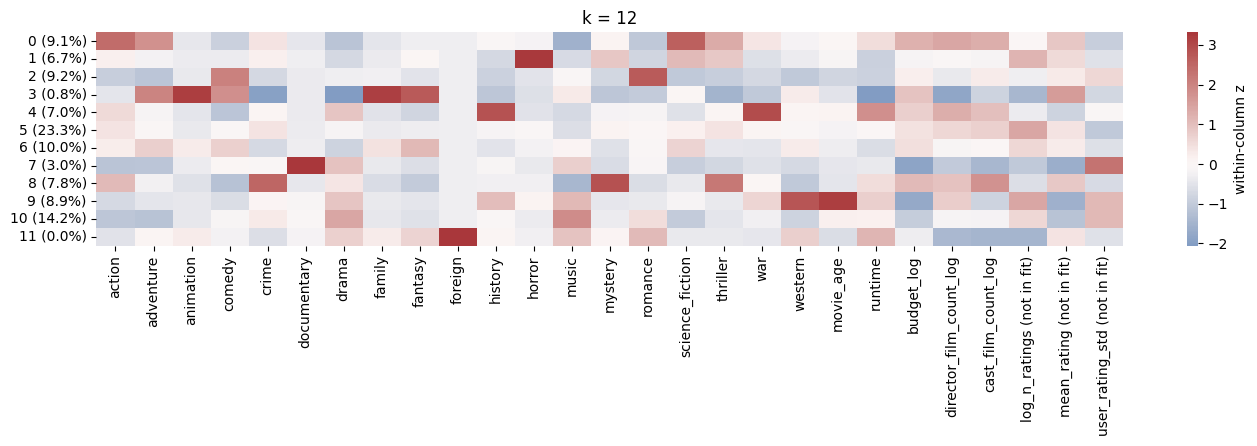

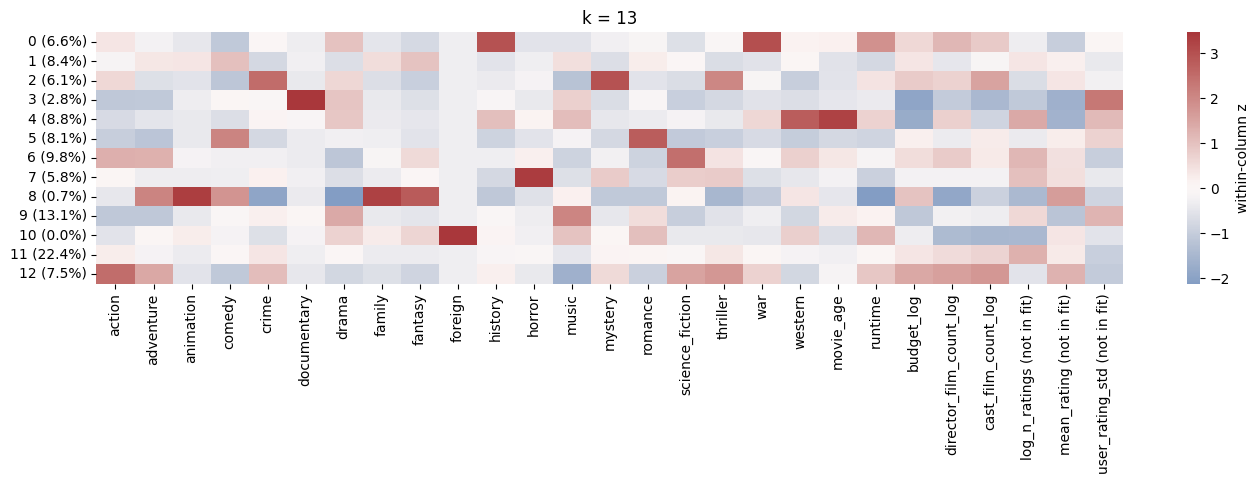

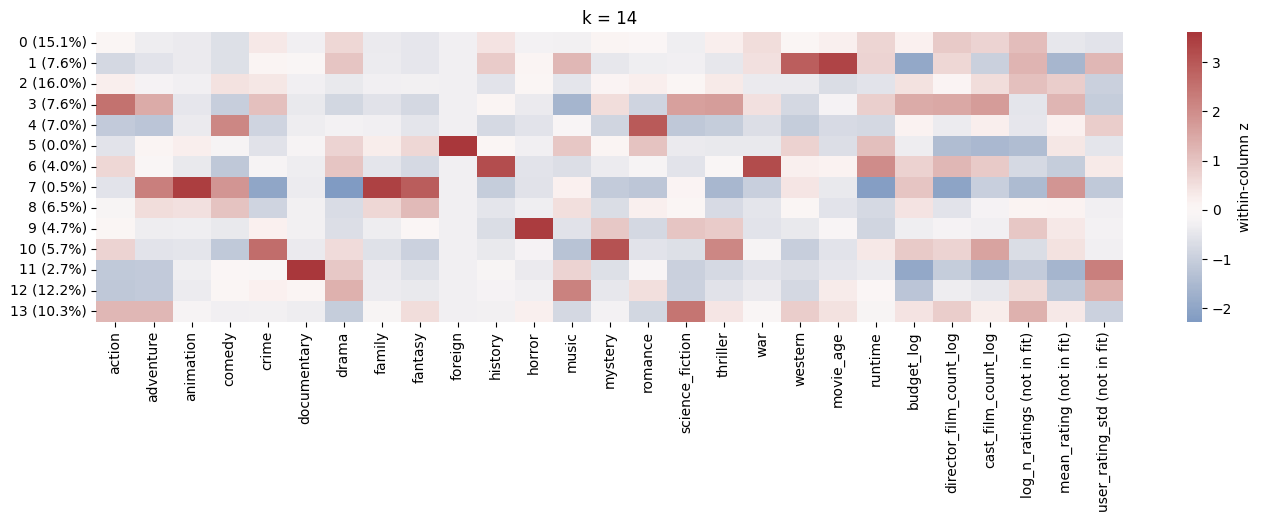

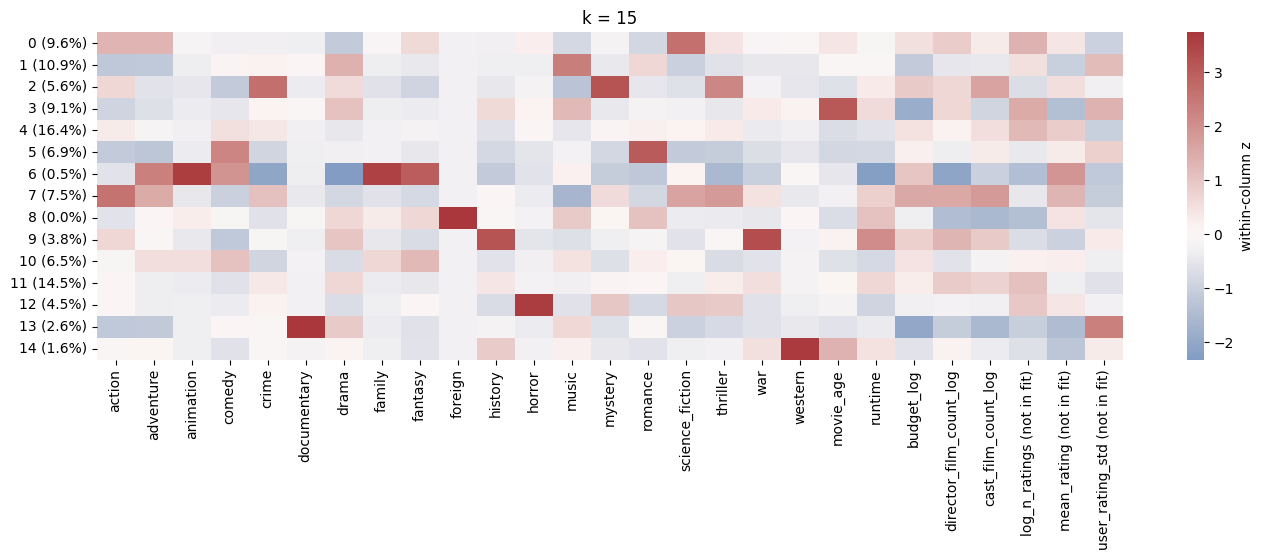

In [ ]:
taste_scaler = StandardScaler()
x_train_taste = taste_scaler.fit_transform(eligible.loc[is_train, taste_cols])
x_test_taste = taste_scaler.transform(eligible.loc[~is_train, taste_cols])
x_scaled_taste = np.empty((len(eligible), len(taste_cols)), dtype=np.float64)
x_scaled_taste[is_train] = x_train_taste
x_scaled_taste[~is_train] = x_test_taste
print(f"Taste train matrix: {x_train_taste.shape}")

labels_taste, inertia_taste = fit_kmeans(x_train_taste, x_test_taste)
silhouette_taste = silhouette_by_k(labels_taste, x_scaled_taste)
plot_fit_curves(inertia_taste, silhouette_taste, "Taste features only")
plot_persona_heatmaps(labels_taste, taste_cols + HABIT_COLS, unused_cols=HABIT_COLS)


## 7. Save assignments

Set `CHOSEN_K` to an integer from 2 through 15 and `CHOSEN_FIT` to `"full"` or `"taste"` to write `data/processed/user_personas.csv` with `customer_id`, `persona_id`, and `split`. Leave either as `None` to skip the save.


In [ ]:
CHOSEN_K = None
CHOSEN_FIT = None

labels_by_fit = {"full": labels_full, "taste": labels_taste}

if CHOSEN_K is None or CHOSEN_FIT is None:
    print("CHOSEN_K or CHOSEN_FIT is unset. Skipping save.")
else:
    if CHOSEN_K not in K_VALUES:
        raise ValueError("CHOSEN_K must be an integer from 2 through 15")
    if CHOSEN_FIT not in labels_by_fit:
        raise ValueError('CHOSEN_FIT must be "full" or "taste"')
    personas = eligible[["customer_id", "split"]].copy()
    personas["persona_id"] = labels_by_fit[CHOSEN_FIT][CHOSEN_K]
    personas = personas[["customer_id", "persona_id", "split"]]
    out_path = PROCESSED / "user_personas.csv"
    personas.to_csv(out_path, index=False)
    print(f"Saved {out_path.name}: {len(personas):,} rows for {CHOSEN_FIT} k={CHOSEN_K}")


CHOSEN_K or CHOSEN_FIT is unset. Skipping save.
